This notebook is to explore the idea that $O'= O-\braket{O}_{h=hc}$ captures the fluctuations of the observable.

In [1]:
import sys 
sys.path.append("../../src")
from common_imports import *

# $\sigma_x \sigma_x$

In [2]:
import equilibrium_critical_correlations as eq
import kibble_zurek as kz

In [3]:
equilibrium_value = eq.sigma_general([0,1])
L = 256
taus = np.logspace(-2,2,50)
xx_prime =[]
for tau in tqdm(taus):
    state = kz.state(L,tau,0)
    sigmasigma = kz.sigma_general([0,1],state)
    xx_prime.append(sigmasigma-equilibrium_value)
xx_prime= array(xx_prime)

  0%|          | 0/50 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/fluctuations_of_mean/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
100%|██████████| 50/50 [00:07<00:00,  6.76it/s]


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2422/383604440.py:5: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ylim(0,1)


(np.float64(0.007943282347242814), 1)

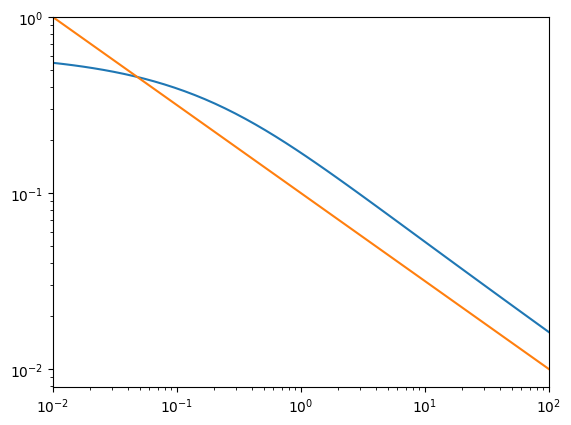

In [4]:
plot(taus,-xx_prime)
plot(taus,taus**(-1/2)/10)
loglog()
xlim(taus[0],taus[-1])
ylim(0,1)

# $\braket{\sigma_z}$

In [59]:
from equilibrium_z_projectors import sigma_general as sigma_zeq

from time_evolved_z_correlators import sigma_general as sigma_z

In [44]:
equilibrium_value = sigma_zeq([0])
L = 256
taus = np.logspace(-2,2,50)
z_prime =[]
for tau in tqdm(taus):
    state = kz.state(L,tau,0)
    sigma = sigma_z([0],state)
    z_prime.append(sigma-equilibrium_value)
z_prime= array(z_prime)

  0%|          | 0/50 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/fluctuations_of_mean/../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)
100%|██████████| 50/50 [00:07<00:00,  6.70it/s]


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_1805/3634133311.py:7: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ylim(0,1)


(np.float64(0.007943282347242814), 1)

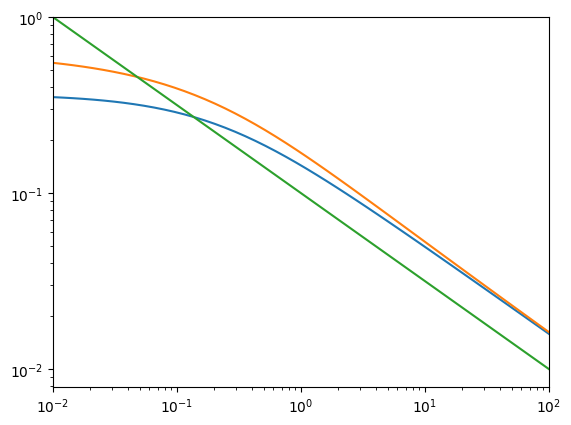

In [49]:
plot(taus,z_prime)
plot(taus,-xx_prime)

plot(taus,taus**(-1/2)/10)
loglog()
xlim(taus[0],taus[-1])
ylim(0,1)

In [62]:
x= (1-sigma_zeq([0]))

print(f"Variance = {x}; \n stdv = {sqrt(x)}")



Variance = 0.3633802276324186; 
 stdv = 0.6028102749890869


In [71]:
r = np.arange(1,200)

In [101]:
x= array([1-eq.sigma_general([0,ri])**2 for ri in r])
y= array([eq.sigma_general([0,ri]) for ri in r])


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


(0.0, 1.0)

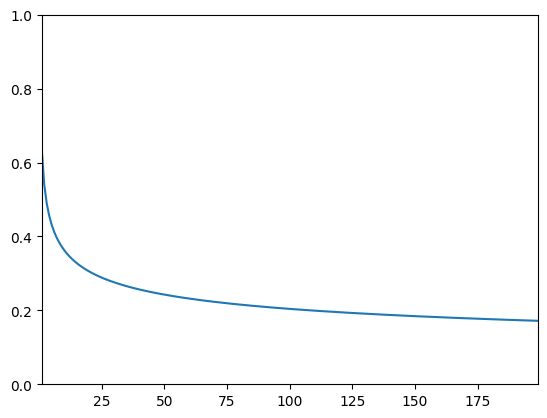

In [102]:
plot(r,y)
xlim(r[0],r[-1])
ylim(0,1)

(0.0, 1.0)

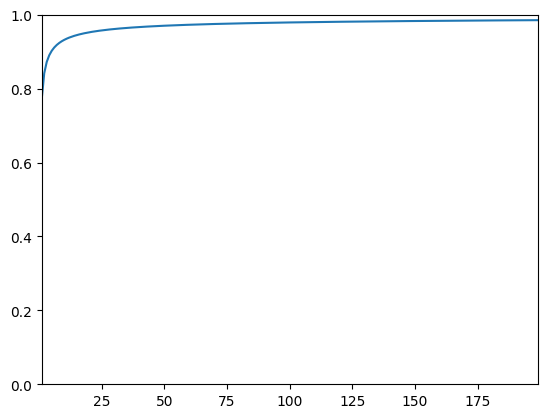

In [103]:
plot(r,sqrt(x))
xlim(r[0],r[-1])
ylim(0,1)
#plot(r,1-r**(-1/2)/2.5)
#loglog()

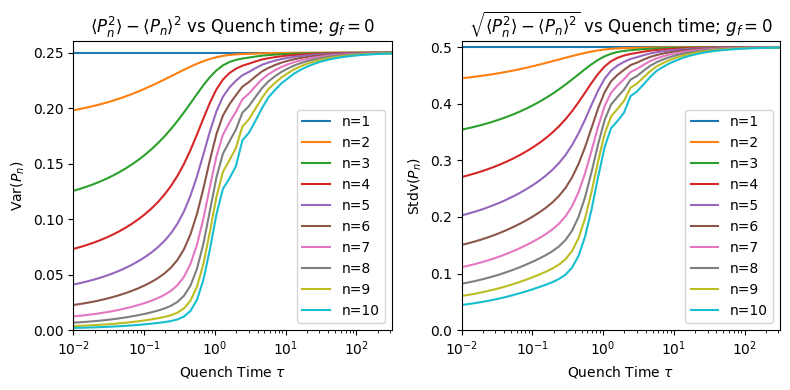

In [199]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True)

for n in range(1, nmax + 1):
    y = Pvar[n-1]
    ax1.plot(taus, y, label=f"n={n}")
    ax2.plot(taus, np.sqrt(y), label=f"n={n}")

# Left: variance
ax1.set_xscale("log")
ax1.set_ylim(0, 0.26)
ax1.set_xlim(taus[0], taus[-1])
ax1.set_title(r"$\langle P_n ^2 \rangle - \langle P_n \rangle^2$ vs Quench time; $g_f=0$")
ax1.set_xlabel(r"Quench Time $\tau$")
ax1.set_ylabel(r"Var$(P_n)$")
ax1.legend()

# Right: standard deviation
ax2.set_xscale("log")
ax2.set_ylim(0, 0.51)
ax2.set_xlim(taus[0], taus[-1])
ax2.set_title(r"$\sqrt{\langle P_n ^2 \rangle - \langle P_n \rangle^2}$ vs Quench time; $g_f=0$")
ax2.set_xlabel(r"Quench Time $\tau$")
ax2.set_ylabel(r"Stdv$(P_n)$")
ax2.legend()

plt.tight_layout()
plt.show()


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2422/1612583905.py:15: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(0, 0.26)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2422/1612583905.py:25: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(0, 0.51)


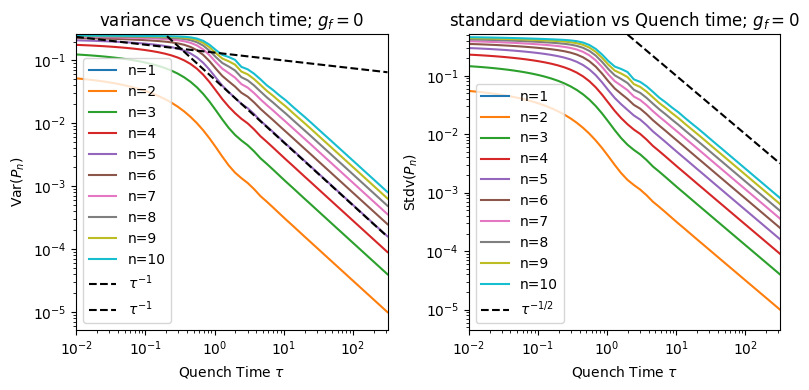

In [223]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True)

for n in range(1, nmax + 1):
    y = Pvar[n-1]
    ax1.plot(taus, 0.25-y, label=f"n={n}")
    ax2.plot(taus, 0.5-np.sqrt(y), label=f"n={n}")
ax1.plot(taus,taus**(-1)/20,color="black",ls="--",label=r"$\tau^{-1}$")
ax1.plot(taus,taus**(-1/8)/7.5,color="black",ls="--",label=r"$\tau^{-1}$")

ax2.plot(taus,taus**(-1),color="black",ls="--",label=r"$\tau^{-1/2}$")

# Left: variance
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylim(0, 0.26)
ax1.set_xlim(taus[0], taus[-1])
ax1.set_title(r"variance vs Quench time; $g_f=0$")
ax1.set_xlabel(r"Quench Time $\tau$")
ax1.set_ylabel(r"Var$(P_n)$")
ax1.legend()

# Right: standard deviation
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_ylim(0, 0.51)
ax2.set_xlim(taus[0], taus[-1])
ax2.set_title(r"standard deviation vs Quench time; $g_f=0$")
ax2.set_xlabel(r"Quench Time $\tau$")
ax2.set_ylabel(r"Stdv$(P_n)$")
ax2.legend()

plt.tight_layout()
plt.show()


In [194]:
import kblock_ising_model as kb

from kibble_zurek import g
k0 = kb.k_vals(L=256)

print(P_gs)

0.5


In [366]:
L = 256
nmax= 10
taus= np.logspace(-2,2.5,50)
Pvar = np.empty([nmax,len(taus)])
for i,tau in tqdm(enumerate(taus)):
    state = kz.state(L,tau,tau)
    for n in range(1,nmax+1):
        Pn = kz.P_n(n,state)
        var = Pn-Pn**2
        Pvar[n-1,i]=var

50it [00:14,  3.52it/s]


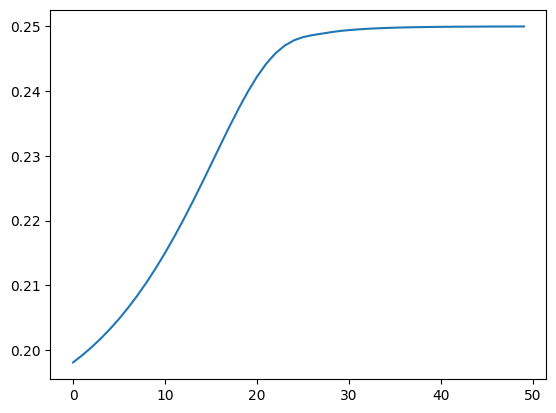

In [384]:
plot(Pvar[1,:])


In [388]:
Pvar[1,:]

array([0.19807096, 0.19918505, 0.20040768, 0.2017471 , 0.20321155,
       0.20480902, 0.20654692, 0.20843168, 0.21046823, 0.21265931,
       0.21500463, 0.2174998 , 0.22013516, 0.22289427, 0.22575237,
       0.22867478, 0.23161552, 0.23451657, 0.23730838, 0.2399127 ,
       0.24224863, 0.24424282, 0.24584339, 0.24703439, 0.24784488,
       0.24834767, 0.24864943, 0.24887195, 0.24909713, 0.24929977,
       0.24942952, 0.24953969, 0.24963019, 0.24970255, 0.24975888,
       0.24980526, 0.24984289, 0.24987268, 0.2498971 , 0.24991679,
       0.24993268, 0.24994556, 0.24995594, 0.24996436, 0.24997115,
       0.24997666, 0.24998111, 0.24998471, 0.24998763, 0.24999   ])

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2422/498275138.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2422/498275138.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ylim(0,.26)


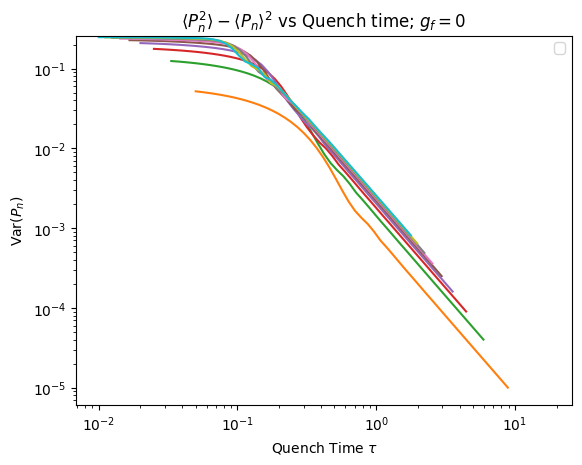

In [408]:
#plot(taus,(.25-Pvar.T),label=[f"n={n}" for n in range(1,nmax+1)])
for i in range(1,nmax+1):
    P = .25-Pvar[i-1,:]
    x = sqrt(taus)/i
    plot(x,P) #,label=[f"n={n}" for n in range(1,nmax+1)])

#plot(taus,taus**(-1),color="black")
legend()
xscale("log")
yscale("log")
ylim(0,.26)
#xlim(taus[0],taus[-1])
plt.title(r"$\langle P_n ^2 \rangle - \langle P_n \rangle^2$ vs Quench time; $g_f=0$")
xlabel(r"Quench Time $\tau$")
ylabel(r"Var$(P_n)$")
show()

# plot(sqrt(taus),sqrt(Pvar.T),label=[f"n={n}" for n in range(1,nmax+1)])
# legend()
# xscale("log")
# #yscale("log")
# ylim(0,.51)
# xlim(taus[0],taus[-1])
# plt.title(r"$\sqrt{\langle P_n ^2 \rangle - \langle P_n \rangle^2}$ vs Quench time; $g_f=0$")
# xlabel(r"Quench Time $\tau$")
# ylabel(r"Stdv$(P_n)$")

In [190]:
L = 256
nmax= 10
taus= np.logspace(-2,2.5,50)
Pvar = np.empty([nmax,len(taus)])
for i,tau in tqdm(enumerate(taus)):
    state = kz.state(L,tau,0)
    for n in range(1,nmax+1):
        Pn = kz.P_n(n,state)
        var = Pn-Pn**2
        Pvar[n-1,i]=var

0it [00:00, ?it/s]/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/fluctuations_of_mean/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
50it [00:13,  3.71it/s]


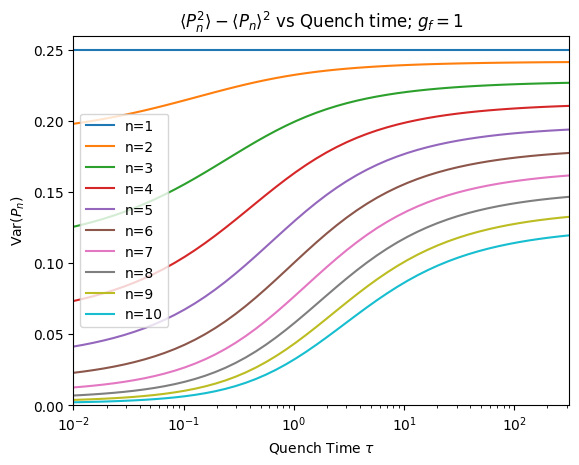

Text(0, 0.5, 'Stdv$(P_n)$')

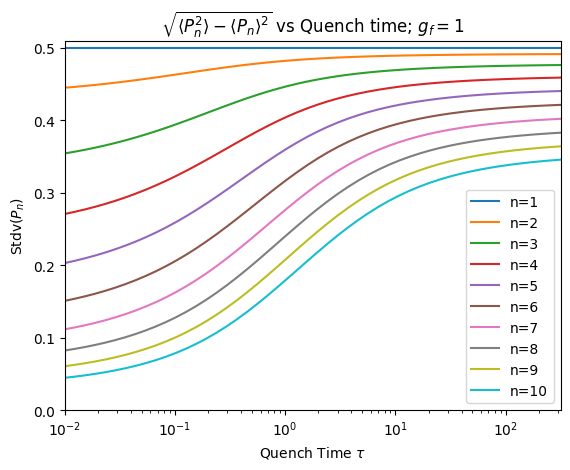

In [191]:
plot(taus,Pvar.T,label=[f"n={n}" for n in range(1,nmax+1)])
legend()
xscale("log")
#yscale("log")
ylim(0,.26)
xlim(taus[0],taus[-1])
plt.title(r"$\langle P_n ^2 \rangle - \langle P_n \rangle^2$ vs Quench time; $g_f=1$")
xlabel(r"Quench Time $\tau$")
ylabel(r"Var$(P_n)$")
show()

plot(taus,sqrt(Pvar.T),label=[f"n={n}" for n in range(1,nmax+1)])
legend()
xscale("log")
#yscale("log")
ylim(0,.51)
xlim(taus[0],taus[-1])
plt.title(r"$\sqrt{\langle P_n ^2 \rangle - \langle P_n \rangle^2}$ vs Quench time; $g_f=1$")
xlabel(r"Quench Time $\tau$")
ylabel(r"Stdv$(P_n)$")

In [192]:
L = 256
nmax= 10
taus= np.logspace(-2,2.5,50)
Pvar = np.empty([nmax,len(taus)])
for i,tau in tqdm(enumerate(taus)):
    state = kz.state(L,tau,-tau)
    for n in range(1,nmax+1):
        Pn = kz.P_n(n,state)
        var = Pn-Pn**2
        Pvar[n-1,i]=var

50it [00:12,  4.04it/s]


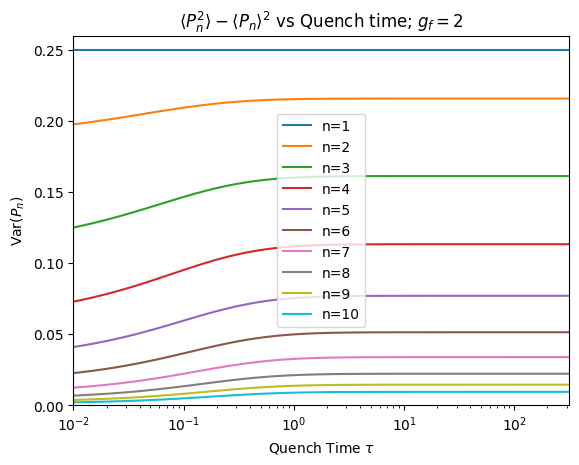

Text(0, 0.5, 'Stdv$(P_n)$')

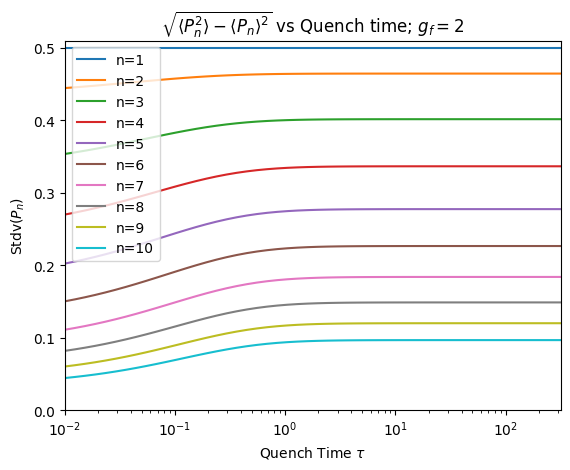

In [193]:
plot(taus,Pvar.T,label=[f"n={n}" for n in range(1,nmax+1)])
legend()
xscale("log")
#yscale("log")
ylim(0,.26)
xlim(taus[0],taus[-1])
plt.title(r"$\langle P_n ^2 \rangle - \langle P_n \rangle^2$ vs Quench time; $g_f=2$")
xlabel(r"Quench Time $\tau$")
ylabel(r"Var$(P_n)$")
show()

plot(taus,sqrt(Pvar.T),label=[f"n={n}" for n in range(1,nmax+1)])
legend()
xscale("log")
#yscale("log")
ylim(0,.51)
xlim(taus[0],taus[-1])
plt.title(r"$\sqrt{\langle P_n ^2 \rangle - \langle P_n \rangle^2}$ vs Quench time; $g_f=2$")
xlabel(r"Quench Time $\tau$")
ylabel(r"Stdv$(P_n)$")

In [225]:
kb.U(k0,0)

(array([0.99998118, 0.99983058, 0.99952942, 0.99907773, 0.99847558,
        0.99772307, 0.9968203 , 0.99576741, 0.99456457, 0.99321195,
        0.99170975, 0.99005821, 0.98825757, 0.9863081 , 0.98421009,
        0.98196387, 0.97956977, 0.97702814, 0.97433938, 0.97150389,
        0.96852209, 0.96539444, 0.9621214 , 0.95870347, 0.95514117,
        0.95143502, 0.94758559, 0.94359346, 0.93945922, 0.93518351,
        0.93076696, 0.92621024, 0.92151404, 0.91667906, 0.91170603,
        0.9065957 , 0.90134885, 0.89596625, 0.89044872, 0.8847971 ,
        0.87901223, 0.87309498, 0.86704625, 0.86086694, 0.85455799,
        0.84812034, 0.84155498, 0.83486287, 0.82804505, 0.82110251,
        0.81403633, 0.80684755, 0.79953727, 0.79210658, 0.7845566 ,
        0.77688847, 0.76910334, 0.76120239, 0.7531868 , 0.74505779,
        0.73681657, 0.72846439, 0.72000251, 0.7114322 , 0.70275474,
        0.69397146, 0.68508367, 0.6760927 , 0.66699992, 0.65780669,
        0.6485144 , 0.63912444, 0.62963824, 0.62

[]

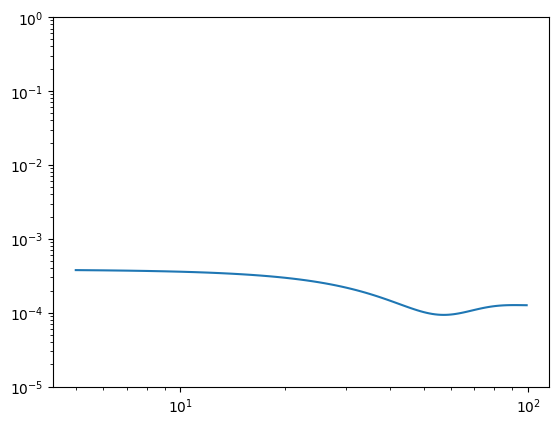

In [272]:
def defect_defect_corr(r, state):
    """
    Defect-defect correlation function
    d_j = (1 - sigma^x_j sigma^x_{j+1})/2
    C_dd(r) = <d_j d_{j+r}>
    expressed via fermion correlators G(r,state).
    """

    G = lambda rr: kz.G(rr, state)

    # expression: 1/4 (1 - 2 G(1) + <σ^x_j σ^x_{j+1} σ^x_{j+r} σ^x_{j+r+1}>)
    # the 4-spin correlator reduces to a determinant/Pfaffian of G's
    term = (
        G(1) * G(1)
        - G(r) * G(-r)
        + G(r + 1) * G(-(r + 1))
        - G(r) * G(-(r + 1))
        - G(r + 1) * G(-r)
    )

    return 0.25 * (1 - 2 * G(1) + term)

tau = 100
state = kz.state(L,tau,tau)
r = np.arange(5,100)

dat = [defect_defect_corr(ri,state) for ri in r]

plot(r,dat)
ylim(0.00001,1)
loglog()

In [341]:


def defect_defect_full(r,state):
    corr2 = kz.sigma_general([0,1],state)
    corr1 = kz.sigma_general([0,1,1+r,2+r],state)
    
    return (1-2*corr2+corr1)/4

def defect(state):
    return (1-kz.sigma_general([0,1],state))/2

def dd_cc(r,state):
    val = defect_defect_full(r,state) - defect(state)**2
    return val


def full_plot(r,tau):
    state = kz.state(512,tau,tau)
    data = array([defect_defect_full(ri,state) for ri in r])
    return data
def cc_plot(r,tau):
    state = kz.state(512,tau,tau)
    data = array([dd_cc(ri,state) for ri in r])
    return data

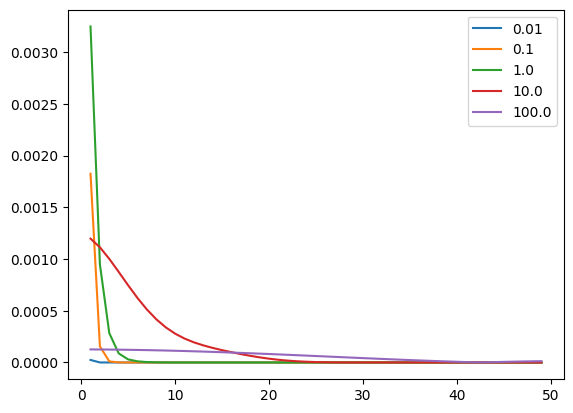

In [349]:
taus = np.logspace(-2,2,5)
r = np.arange(1,50)
for tau in taus:
    x = abs(cc_plot(r,tau))
    plot(r,x,label=tau)

legend()

#yscale("log")

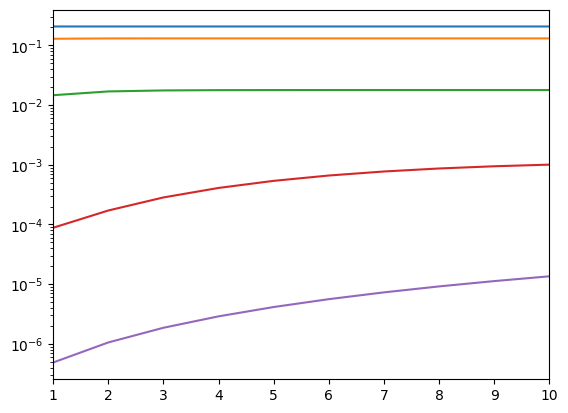

In [354]:
taus = np.logspace(-2,2,5)
r = np.arange(1,11)
for tau in taus:
    x = abs(full_plot(r,tau))
    plot(r,x)

xlim(1,10)
yscale("log")

In [355]:

def n_plot_full(r,taus):
    data= []
    for tau in taus:
        state = kz.state(512,tau,tau)
        data.append(defect_defect_full(r,state))
    return array(data)
def n_plot_cc(r,taus):
    data= []
    for tau in taus:
        state = kz.state(512,tau,tau)
        data.append(dd_cc(r,state))
    return array(data)

/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/fluctuations_of_mean/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


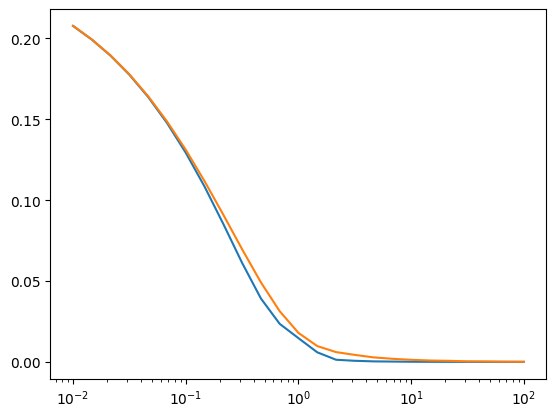

In [364]:
plot(taus,n_plot_full(1,taus))
plot(taus,n_plot_full(25,taus))

xscale("log")

/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/fluctuations_of_mean/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


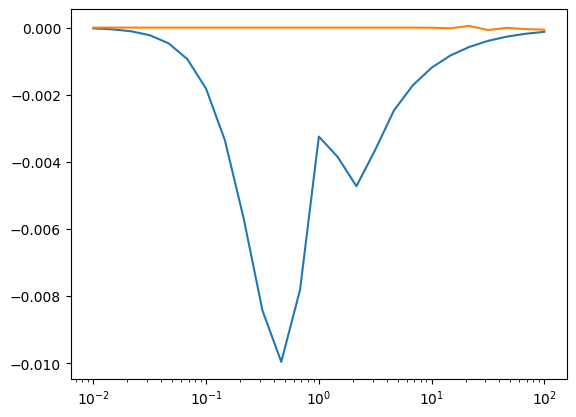

In [363]:
plot(taus,n_plot_cc(1,taus))
plot(taus,n_plot_cc(25,taus))

xscale("log")

In [ ]:
states=[]
for tau in tqdm(taus):
    states.append( kz.state(L,tau,0))

In [421]:
from equilibrium_z_projectors import P_n as Pz_ex

from time_evolved_z_correlators import P_n as Pz_t

In [422]:
n= 10

data=[]
data2=[]
P0 = eq.P_n(n)
P0z = Pz_ex(n)
for state in states:
    Pn = kz.P_n(n,state)
    Pnz= Pz_t(n,state)
    data.append(abs(P0-Pn))
    data2.append(abs(P0z-Pnz))
data2=array(data2)

data=array(data)

/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/fluctuations_of_mean/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/fluctuations_of_mean/../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)


[]

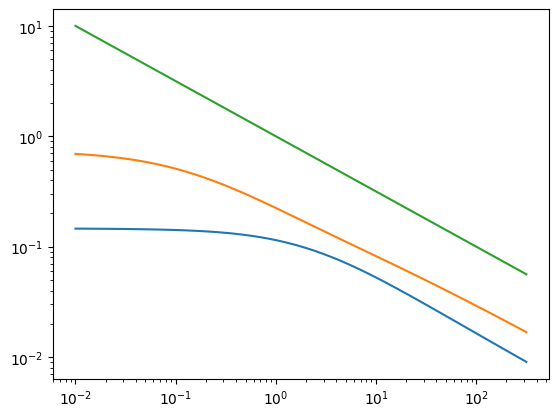

In [423]:
plot(taus,data)
plot(taus,data2)
plot(taus,taus**(-1/2))
loglog()

In [445]:
def timestates(L,tau):
    t = np.linspace(-2*tau,tau,100)
    return array([kz.state(L,tau,ti) for ti in t])

timesteps = timestates(256,1)
timesteps2= timestates(256,100)

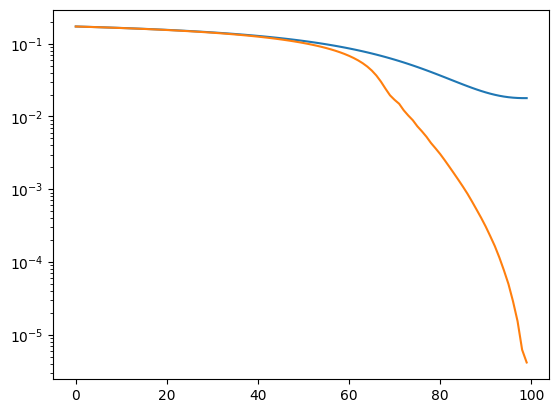

In [446]:
dat= array([defect_defect_full(5,s) for s in timesteps])
plot(dat)
dat= array([defect_defect_full(5,s) for s in timesteps2])
plot(dat)
yscale("log")

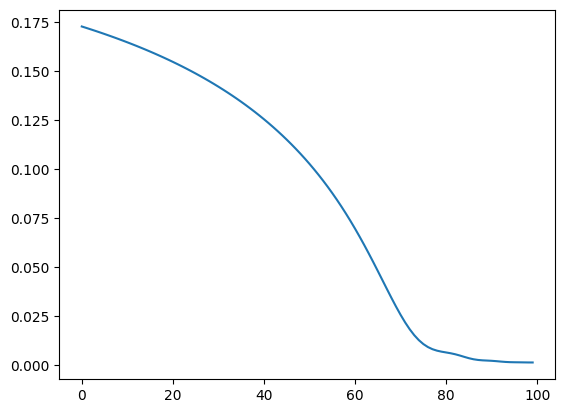